# 3. Classificação e Avaliação
Este notebook carrega as features extraídas, realiza a divisão estratificada dos dados, aplica padronização sem vazamento de informação e treina classificadores clássicos.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

X = pd.read_csv('../outputs/X.csv')
y = pd.read_csv('../outputs/y.csv').squeeze()

### ==========================================
## 1.5 ANÁLISE VISUAL DAS FEATURES (BOXPLOTS)
### ==========================================

/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
/tmp/ipykernel_38145/4058411627.py:15: FutureWarning: 

Passing `palette` without assigning

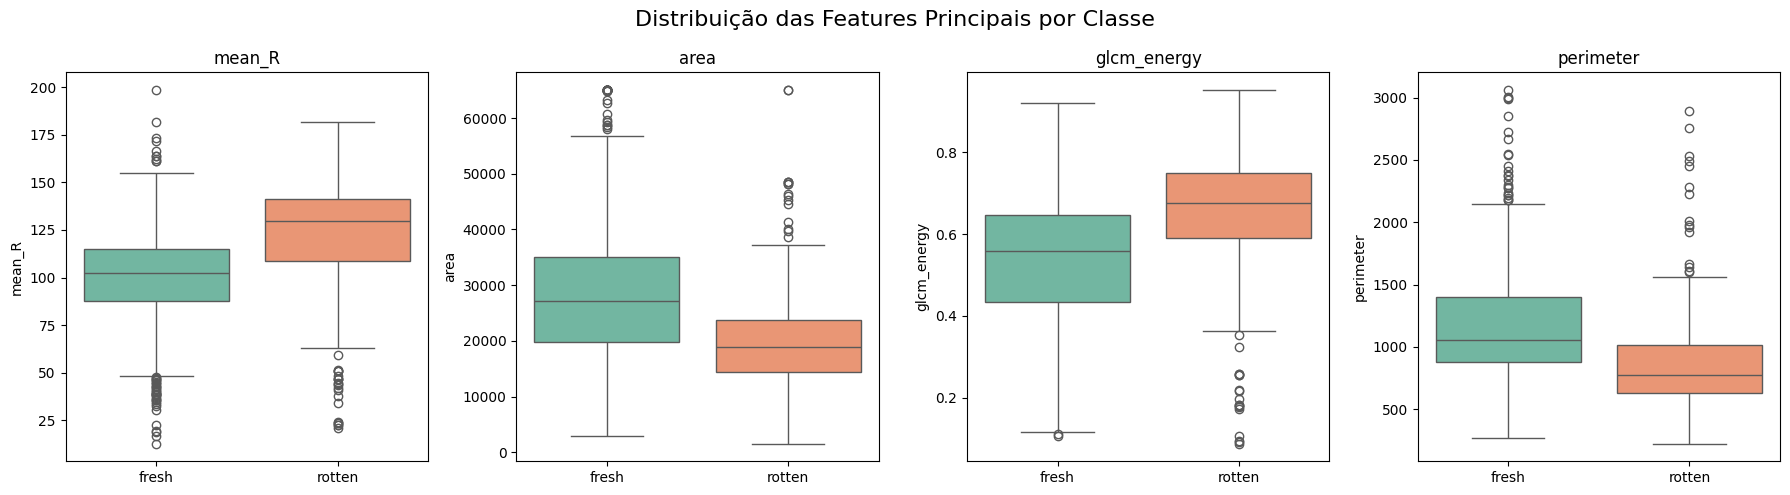

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Juntando X e y temporariamente apenas para facilitar o plot
df_analise = X.copy()
df_analise['label'] = y

# Selecionando as features que sabemos que são mais impactantes (via SHAP)
features_chave = ['mean_R', 'area', 'glcm_energy', 'perimeter']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribuição das Features Principais por Classe', fontsize=16)

for i, feature in enumerate(features_chave):
    sns.boxplot(x='label', y=feature, data=df_analise, ax=axes[i], palette='Set2')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## Divisão Estratificada e Pré-Processamento
Divisão dos dados em treino (60%), validação (20%) e teste (20%). O StandardScaler é ajustado exclusivamente nos dados de treino.

In [50]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Treinamento e Avaliação
Treinamento do Random Forest e Support Vector Machine (SVM), seguido da avaliação quantitativa e visualização das matrizes de confusão nos dados de teste reservados.

              precision    recall  f1-score   support

       fresh       0.89      0.83      0.86       120
      rotten       0.84      0.90      0.87       120

    accuracy                           0.87       240
   macro avg       0.87      0.87      0.87       240
weighted avg       0.87      0.87      0.87       240



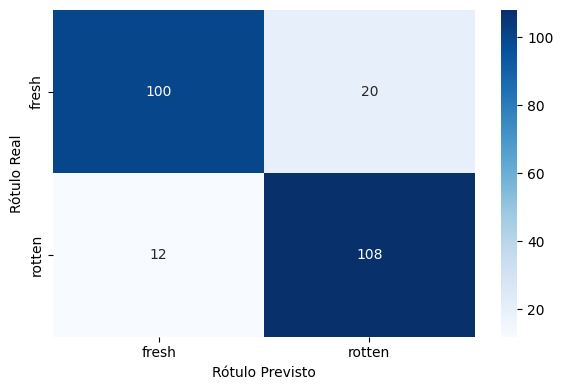

              precision    recall  f1-score   support

       fresh       0.84      0.84      0.84       120
      rotten       0.84      0.84      0.84       120

    accuracy                           0.84       240
   macro avg       0.84      0.84      0.84       240
weighted avg       0.84      0.84      0.84       240



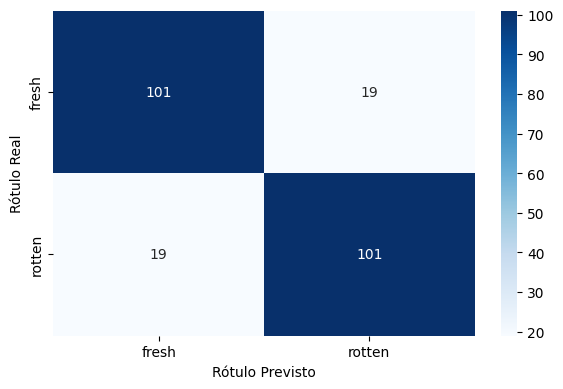

In [51]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

def evaluate_model(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.ylabel('Rótulo Real')
    plt.xlabel('Rótulo Previsto')
    plt.tight_layout()
    plt.show()

evaluate_model(rf_model, X_test_scaled, y_test)
evaluate_model(svm_model, X_test_scaled, y_test)

In [52]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def test_single_image(image_path, model, scaler, feature_columns):
    # 1. Load Image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not load image.")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Apply the Otsu Segmentation (from Notebook 01/02)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Isolate the fruit for visualization
    isolated_fruit = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    
    # 3. Extract Features (from Notebook 02)
    # Note: ensure your extract_features function is loaded in memory
    features = extract_features(img_rgb, mask)
    
    if features is None:
        print("Could not find any object in the image.")
        return

    # 4. Prepare data for prediction
    df_features = pd.DataFrame([features])
    
    # Ensure columns match the exact order of the training data
    df_features = df_features[feature_columns]
    
    # Apply the scaler fitted on the training data
    scaled_features = scaler.transform(df_features)
    
    # Predict using the Random Forest
    prediction = model.predict(scaled_features)[0]
    probabilities = model.predict_proba(scaled_features)[0]
    confidence = max(probabilities) * 100
    
    # 5. Plot the visual breakdown
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"AI VERDICT: {prediction.upper()} ({confidence:.1f}% confidence)", fontsize=18, fontweight='bold', color='darkred' if prediction=='rotten' else 'darkgreen')
    
    axs[0].imshow(img_rgb)
    axs[0].set_title("1. Original Photo")
    axs[0].axis('off')
    
    axs[1].imshow(mask, cmap='gray')
    axs[1].set_title("2. AI Segmentation (What it focuses on)")
    axs[1].axis('off')
    
    axs[2].imshow(isolated_fruit)
    axs[2].set_title("3. Final Object Analyzed")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 6. Print the numerical features the AI extracted
    print("-" * 40)
    print("NUMERICAL FEATURES EXTRACTED BY THE AI:")
    print("-" * 40)
    for k, v in features.items():
        print(f"{k.ljust(20)}: {v:.4f}")

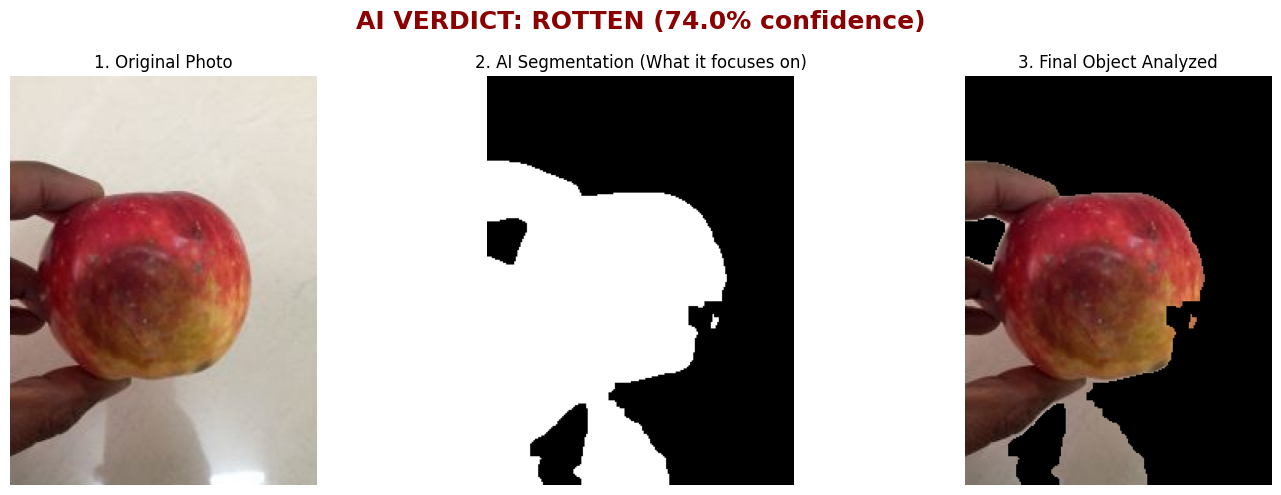

----------------------------------------
NUMERICAL FEATURES EXTRACTED BY THE AI:
----------------------------------------
area                : 20817.5000
perimeter           : 898.6589
circularity         : 0.3239
hu_moment_0         : 0.7004
hu_moment_1         : 2.4021
hu_moment_2         : 3.1131
hu_moment_3         : 4.0726
hu_moment_4         : 7.6657
hu_moment_5         : 5.2801
hu_moment_6         : -9.2537
mean_R              : 125.2337
mean_G              : 67.5450
mean_B              : 57.8498
glcm_contrast       : 168.7794
glcm_correlation    : 0.9632
glcm_energy         : 0.5635
glcm_homogeneity    : 0.7043


In [53]:
test_image = "/home/akdag/Desktop/vis_computacional/dataset/bad_quality_fruits/Apple_Bad/IMG_8142.JPG"

# Pass the trained Random Forest (rf_model), the scaler, and the column names from X
test_single_image(test_image, rf_model, scaler, X.columns)

In [54]:
import joblib
import os

os.makedirs('../outputs/modelos', exist_ok=True)

# Salvando o modelo e o padronizador
joblib.dump(rf_model, '../outputs/modelos/rf_model.pkl')
joblib.dump(scaler, '../outputs/modelos/scaler.pkl')

# Salvando as colunas exatas usadas no treinamento
joblib.dump(X.columns.tolist(), '../outputs/modelos/colunas.pkl')

print("Modelos exportados com sucesso para o Streamlit!")

Modelos exportados com sucesso para o Streamlit!
